# Syndrome-based NN BCH code decoder

In [1]:
import numpy as np
import pyldpc as ldpc
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers.core import Dense, Lambda
from keras import backend as K
from tqdm.keras import TqdmCallback
import os.path, sys, bz2
%matplotlib inline
%config InlineBackend.figure_format='retina'
tf.config.list_physical_devices('GPU')

[]

## Generate codebook

In [2]:
def getBinaryMatrix(source):
    source = os.path.expanduser(source)
    fileObj = bz2.BZ2File(source, 'r') if source.endswith('bz2') else open(source, 'rt')
    with fileObj as f:
        lines = [[int(x) for x in l.strip().split()]
                  for l in f.readlines()
                  if len(l.strip()) > 0]

    if lines[0][0] in (0, 1):  # explicit 0/1 representation
        return np.array(lines, dtype=np.int)
    return alistToNumpy(lines)

def alistToNumpy(lines):
    nCols, nRows = lines[0]
    if len(lines[2]) == nCols and len(lines[3]) == nRows:
        startIndex = 4
    else:
        startIndex = 2
    matrix = np.zeros((nRows, nCols), dtype=int)
    for col, nonzeros in enumerate(lines[startIndex:startIndex + nCols]):
        for rowIndex in nonzeros:
            if rowIndex != 0:
                matrix[rowIndex - 1, col] = 1
    return matrix

In [3]:
k = 7
N = 15
T = 2

In [4]:
H = getBinaryMatrix('source/BCH_15_7_2_strip.alist')
G = ldpc.coding_matrix(H, sparse=False).T

In [5]:
def full_adder(a,b,c):
    s = (a ^ b) ^ c
    c = (a & b) | (c & (a ^ b))
    return s,c

def add_bool(a,b):
    if len(a) != len(b):
        raise ValueError('arrays with different length')
    k = len(a)
    s = np.zeros(k,dtype=bool)
    c = False
    for i in reversed(range(0,k)):
        s[i], c = full_adder(a[i],b[i],c)    
    if c:
        warnings.warn("Addition overflow!")
    return s

def inc_bool(a):
    k = len(a)
    increment = np.hstack((np.zeros(k-1,dtype=bool), np.ones(1,dtype=bool)))
    a = add_bool(a,increment)
    return a

In [6]:
inputs = np.zeros((2**k,k),dtype=bool)
for i in range(1,2**k):
    inputs[i]= inc_bool(inputs[i-1])
codewords = inputs @ G % 2

## Define NN parameters

In [7]:
nb_epoch = 2**12
batch_size = 1024
optimizer = 'adam'
loss = 'bce'

In [9]:
def errors(y_true, y_pred):
    return K.sum(int(K.not_equal(y_true, K.round(y_pred))))

def compose_model(layers):
    model = Sequential()
    for layer in layers:
        model.add(layer)
    return model

In [10]:
NN_layers = [Dense(32, activation='relu'),
             Dense(16, activation='relu'),
             Dense(N, activation='sigmoid')]

error_estimation_rec = compose_model(NN_layers)
error_estimation_rec.compile(optimizer=optimizer, loss=loss, metrics=[errors])

error_estimation_full = compose_model(NN_layers)
error_estimation_full.compile(optimizer=optimizer, loss=loss, metrics=[errors])

## Train model

### Approach 1. Train NN on the syndromes of error vectors with weight $\leq$ 2

In [11]:
# BCH(15,7) code allows to correct two error bits in a codeword.
# Training set contains all possible syndromes from error vectors with weight less or equal to two
error_vectors_rec = np.zeros(N, dtype=int)
channel_values = np.zeros((2**N,N),dtype=bool)
for i in range(1,2**N):
    channel_values[i] = inc_bool(channel_values[i-1])
    if np.sum(channel_values[i]) <= 2:
        error_vectors_rec = np.vstack((error_vectors_rec, channel_values[i]))
syndromes_rec = error_vectors_rec @ H.T % 2

In [12]:
error_vectors_rec.shape

(121, 15)

In [14]:
nb_epoch = 2**12
history_rec = error_estimation_rec.fit(syndromes_rec, error_vectors_rec, batch_size=batch_size, epochs=nb_epoch,
                      shuffle=True, verbose=0, callbacks=[TqdmCallback(verbose=0)])

0epoch [00:00, ?epoch/s]

### Approach 2. Train NN on all the possible syndromes and corresponding error vectors with the least weight

In [32]:
# Generate array with all possible 15-bit combinations
combinations = np.zeros((2**N,N),dtype=bool)
for i in range(1,2**N):
    combinations[i] = inc_bool(combinations[i-1])

In [33]:
# Syndrome can take value in range from b00000000 to b11111111, so zero axis of matrix must have size of 256.
# Possible channel values will be assigned to the 1st and 2nd axis of the matrix.
# Initial matrix is filled with inf valeus
errors_sorted = np.full((2**(N-k), 2**N, N), np.inf)
for i, elem in enumerate(combinations):
    synd = int(np.packbits((elem @ H.T % 2), bitorder='little'))     # Calculate syndrom and convert in to int index 
    errors_sorted[synd][i] = elem                                    # Distribute possible channel states according to syndrom values

In [34]:
# Create LUT: syndrome - error vector with the least weight
error_vectors_full = np.zeros((2**(N-k), N), dtype=int)
for i in range(0, 2**(N-k)):
    error_vectors_full[i] = errors_sorted[i][np.argmin(np.sum(errors_sorted, axis=2)[i])]
syndromes_full = error_vectors_full @ H.T % 2

In [53]:
error_vectors_full.shape

(256, 15)

In [35]:
nb_epoch = 2**16
history_full = error_estimation_full.fit(syndromes_full, error_vectors_full, batch_size=batch_size, epochs=nb_epoch,
                      shuffle=True, verbose=0, callbacks=[TqdmCallback(verbose=0)])

0epoch [00:00, ?epoch/s]

## Evaluate the model in AWGN channel

In [15]:
def encode(x):
    return x @ G % 2

def modulateBPSK(x):
    return -2*x +1;

def addNoise(x, sigma):
    w = np.random.normal(loc=0, scale=sigma, size=(N,))
    return x + w

def demodulateBPSK(x):
    return (-(np.sign(x) - 1)/2).astype(int)

def find_syndrome(x):
    return x @ H.T % 2

In [16]:
test_size = 10**3

SNR_dB_start_Eb = -10
SNR_dB_stop_Eb = 8
SNR_points = 18

SNR_dB_start_Es = SNR_dB_start_Eb + 10*np.log10(k/N)
SNR_dB_stop_Es = SNR_dB_stop_Eb + 10*np.log10(k/N)

sigma_start = np.sqrt(1/(2*10**(SNR_dB_start_Es/10)))
sigma_stop = np.sqrt(1/(2*10**(SNR_dB_stop_Es/10)))
sigmas = np.linspace(sigma_start, sigma_stop, SNR_points)

nb_bit_errors_rec = np.zeros(len(sigmas), dtype=int)
nb_frame_errors_rec = np.zeros(len(sigmas), dtype=int)
nb_bit_errors_full = np.zeros(len(sigmas), dtype=int)
nb_frame_errors_full = np.zeros(len(sigmas), dtype=int)
nb_bits = np.zeros(len(sigmas), dtype=int)
nb_frames = np.zeros(len(sigmas), dtype=int)

In [ ]:
for i, sigma in enumerate(sigmas):
    while nb_bit_errors_rec[i] < test_size:
        idx = np.random.randint(0, 2**k)
        cw = encode(inputs[idx])
        s = modulateBPSK(cw)
        y = addNoise(s, sigma)
        y = demodulateBPSK(y)
        synd = tf.reshape(find_syndrome(y), (1, N-k))
        x_hat_rec = y ^ np.round(error_estimation_rec.predict(synd)).astype(int)     # Get error vector with NN
        x_hat_full = y ^ np.round(error_estimation_full.predict(synd)).astype(int)     # Get error vector with NN
        nb_bit_errors_rec[i] += np.sum(np.not_equal(inputs[idx], x_hat_rec[0][N-k:]))                     
        nb_frame_errors_rec[i] += np.any(np.not_equal(inputs[idx], x_hat_rec[0][N-k:])).astype(int)
        nb_bit_errors_full[i] += np.sum(np.not_equal(inputs[idx], x_hat_full[0][N-k:]))                     
        nb_frame_errors_full[i] += np.any(np.not_equal(inputs[idx], x_hat_full[0][N-k:])).astype(int)
        nb_bits[i] += k
        nb_frames[i] += 1
        print(f'{i+1} | {nb_bit_errors_rec[i]} | {nb_frames[i]}        ', end='\r')

In [18]:
ber_rec = nb_bit_errors_rec/nb_bits
fer_rec = nb_frame_errors_rec/nb_frames
ber_full = nb_bit_errors_full/nb_bits
fer_full = nb_frame_errors_full/nb_frames

In [19]:
conv_sigmas = np.loadtxt('results/BCH/conventional_syndrome_BCH157_-10_5_sigmas.txt')

In [20]:
conv_ber = np.loadtxt('results/BCH/conventional_syndrome_BCH157_-10_5_ber.txt')

In [21]:
conv_fer = np.loadtxt('results/BCH/conventional_syndrome_BCH157_-10_5_fer.txt')

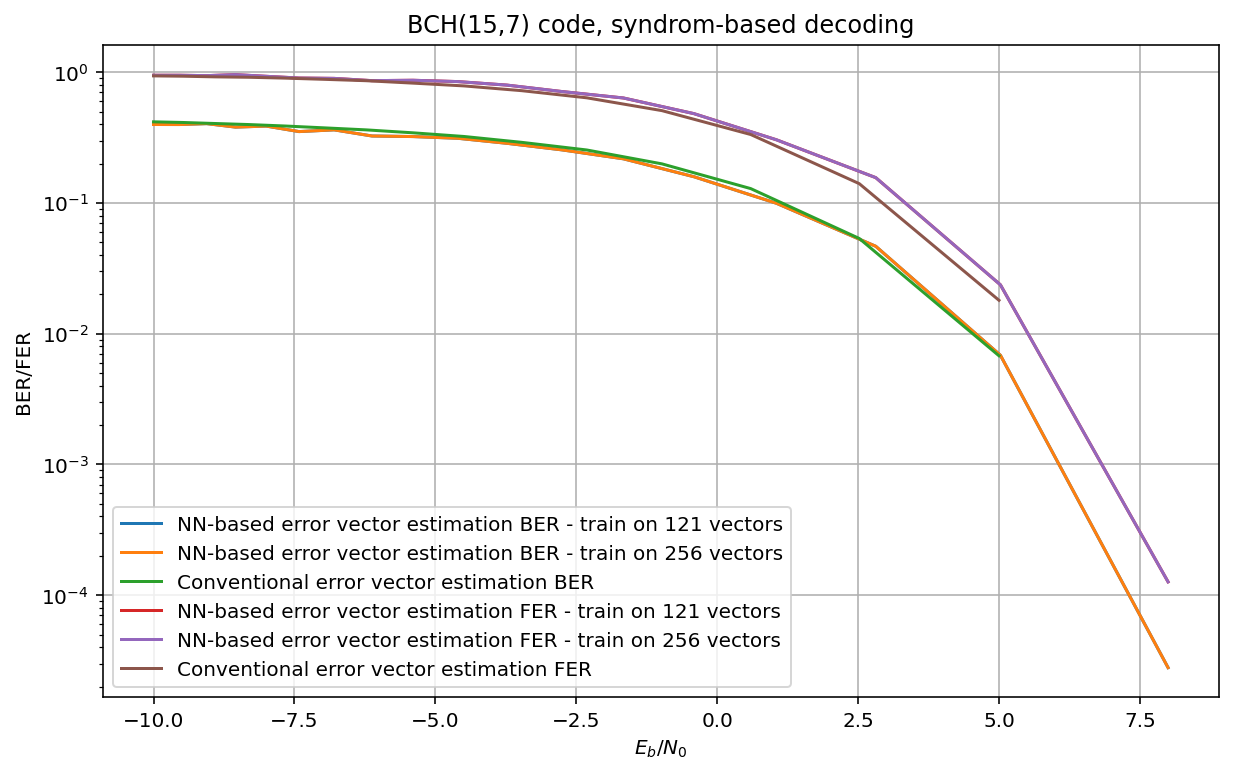

In [22]:
plt.figure(figsize = (10, 6))
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber_rec)
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber_full)
plt.plot(10*np.log10(1/(2*conv_sigmas**2)) - 10*np.log10(k/N), conv_ber)
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer_rec)
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer_full)
plt.plot(10*np.log10(1/(2*conv_sigmas**2)) - 10*np.log10(k/N), conv_fer)
plt.legend(['NN-based error vector estimation BER - train on 121 vectors',
            'NN-based error vector estimation BER - train on 256 vectors',
            'Conventional error vector estimation BER',
            'NN-based error vector estimation FER - train on 121 vectors',
            'NN-based error vector estimation FER - train on 256 vectors',
            'Conventional error vector estimation FER'])
plt.yscale('log')
plt.xlabel('$E_b/N_0$')
plt.ylabel('BER/FER')
plt.title('BCH(15,7) code, syndrom-based decoding')
plt.grid()

In [23]:
np.savetxt('results/BCH/NN_syndrome_BCH157_-10_5_ber.txt', ber_rec)
np.savetxt('results/BCH/NN_syndrome_BCH157_-10_5_fer.txt', fer_rec)
np.savetxt('results/BCH/NN_syndrome_BCH157_-10_5_sigmas.txt', sigmas)